In [ ]:
!pip install pandas
!pip install matplotlib
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

In [11]:
# Merge files - set path to scraped files
file_paths = glob.glob('C:/Users/kefer/OneDrive - Hochschule Luzern/MDS Sem 2/CIP/Basel/data/*.csv')

# Load all files and concatenate them into a single DataFrame, handle special characters if any
dataframes = [pd.read_csv(file, encoding='ISO-8859-1') for file in file_paths]
merged_data = pd.concat(dataframes, ignore_index=True)

# Separate Arrivals and Departures
arrivals_data = merged_data[merged_data['Type'] == 'Arrivals']
departures_data = merged_data[merged_data['Type'] == 'Departures']

# Concatenate Arrivals first and then Departures
final_data = pd.concat([arrivals_data, departures_data], ignore_index=True)

print(final_data)

# Save the final combined data to a single CSV file
final_data.to_csv('C:/Users/kefer/OneDrive - Hochschule Luzern/MDS Sem 2/CIP/Basel/data/combined_flight_data.csv', index=False)


            Type   Time Expected       Origin/Destination  \
0       Arrivals   5:15     5:14                    Liege   
1       Arrivals   5:15     5:07                 Brussels   
2       Arrivals   5:20     5:11             Cologne Bonn   
3       Arrivals   5:25     5:22  Paris Charles De Gaulle   
4       Arrivals   5:25     6:08                    Lille   
...          ...    ...      ...                      ...   
2606  Departures  21:00      NaN                   Skopje   
2607  Departures  21:00      NaN             London Luton   
2608  Departures  21:05      NaN                Barcelona   
2609  Departures  21:40      NaN               Manchester   
2610  Departures  21:45      NaN           London Gatwick   

                           Airline Flight Number           Status   Note  \
0                            FedEx        FX4862     Landed 05:11  Cargo   
1     European Air Transport / DHL        QY4908     Landed 05:05  Cargo   
2                        Sprintair     

In [12]:
# Load the combined file into a new DataFrame
df = pd.read_csv('C:/Users/kefer/OneDrive - Hochschule Luzern/MDS Sem 2/CIP/Basel/data/combined_flight_data.csv')

# Drop the irrelevant columns 
df.drop(columns=['Note'], inplace=True)
df.drop(columns=['Flight Number'], inplace=True)

# Add column LocalAirport
df['LocalAirport'] = 'Basel'

# Check for missing data in all columns
missing_data_summary = df.isna().sum()
print("Missing Data Summary:")
print(missing_data_summary)

# Extract the time part (HH:MM) from 'Status' and store it in a new column 'Actual' 
df['Actual'] = df['Status'].str.extract(r'(\d{2}:\d{2})')

# Ensure appropriate data types of relevant columns with datetime format for computing delay
reference_date = '01-01-2000'  # Any arbitrary reference date

# Function to convert time to datetime with a reference date
def time_to_datetime(time_col):
    return pd.to_datetime(reference_date + ' ' + time_col.astype(str), format='%d-%m-%Y %H:%M', errors='coerce')

# Apply conversion to columns 'Time', 'Expected', and 'Actual'
df['Time'] = time_to_datetime(df['Time'])
df['Expected'] = time_to_datetime(df['Expected'])
df['Actual'] = time_to_datetime(df['Actual'])

# Handle missing values - set 'Status' and 'Actual' to NaN where 'Status' is empty
df.loc[df['Status'].isna() | (df['Status'] == ''), ['Status', 'Actual']] = np.nan

# Handle missing airlines
df['Airline'] = df['Airline'].replace(["", " ", "None", "N/A"], np.nan)
df['Airline'] = df['Airline'].fillna('Unknown')

# For 'Departures', fill 'Expected' with 'Actual' if 'Expected' is empty.
df.loc[(df['Type'] == 'Departures') & (df['Expected'].isna()) & df['Actual'].notna(), 'Expected'] = df['Actual']
df.loc[(df['Type'] == 'Departures') & df['Actual'].isna(), ['Expected', 'Actual']] = np.nan

# Convert 'Expected' and 'Actual' columns to datetime format
df['Expected'] = pd.to_datetime(df['Expected'], format='%H:%M', errors='coerce')
df['Actual'] = pd.to_datetime(df['Actual'], format='%H:%M', errors='coerce')

# Remove rows where Status is 'cancelled', 'boarding closed', or is empty
df = df[~df['Status'].str.lower().isin(['cancelled', 'boarding closed']) & df['Status'].notna() & (df['Status'] != '')]

# Data enrichment - Calculate the time delay in minutes and add 'Delay' as a new column
df['Delay'] = (df['Actual'] - df['Expected']).dt.total_seconds() / 60  # Delay in minutes

# Set Delay to zero when the delay is exactly zero
df['Delay'] = df['Delay'].apply(lambda x: 0 if x == 0 else x)

# Remove the time from 'Status' column, leaving only the descriptive text
df['Status'] = df['Status'].str.replace(r'\d{2}:\d{2}', '', regex=True).str.strip()

# Clean 'Status' column to remove any special characters
df['Status'] = df['Status'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True).str.strip()

# Replace NaN values with the string "NaN" before saving to CSV
df.fillna(np.nan, inplace=True)

# Ensure columns are in the desired order
df = df[['Date Scraped', 'Type', 'LocalAirport', 'Origin/Destination', 'Airline', 'Status', 'Expected', 'Actual', 'Delay']]

# Save the updated DataFrame to a new file
df.to_csv('C:/Users/kefer/OneDrive - Hochschule Luzern/MDS Sem 2/CIP/Basel/data/combined_flight_data_with_actual_cleaned.csv', index=False)

# Print the DataFrame to verify the changes
print(df)

Missing Data Summary:
Type                     0
Time                     0
Expected              1129
Origin/Destination       0
Airline                  4
Status                  16
Date Scraped             0
LocalAirport             0
dtype: int64
        Date Scraped        Type LocalAirport       Origin/Destination  \
0     24-10-24 23:55    Arrivals        Basel                    Liege   
1     24-10-24 23:55    Arrivals        Basel                 Brussels   
2     24-10-24 23:55    Arrivals        Basel             Cologne Bonn   
3     24-10-24 23:55    Arrivals        Basel  Paris Charles De Gaulle   
4     24-10-24 23:55    Arrivals        Basel                    Lille   
...              ...         ...          ...                      ...   
2606  10-11-24 23:55  Departures        Basel                   Skopje   
2607  10-11-24 23:55  Departures        Basel             London Luton   
2608  10-11-24 23:55  Departures        Basel                Barcelona   
2609  10-

### RQ 1: Top 5 most frequent Origins of arriving flights over the past 2 weeks

Top 5 Most Frequent Origins of Arriving Flights:
Origin/Destination
Pristina                   67
Amsterdam                  58
Frankfurt                  57
London Heathrow            49
Paris Charles De Gaulle    41
Name: count, dtype: int64


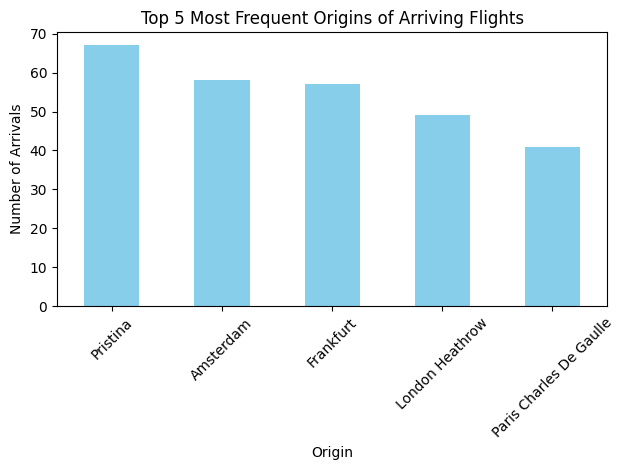

In [13]:
# Load the cleaned data
df = pd.read_csv('C:/Users/kefer/OneDrive - Hochschule Luzern/MDS Sem 2/CIP/Basel/data/combined_flight_data_with_actual_cleaned.csv')

# Filter for Arrivals only
arrivals_df = df[df['Type'] == 'Arrivals']

# Find the top five most frequent origins
top_origins = arrivals_df['Origin/Destination'].value_counts().head(5)

# Display the result
print("Top 5 Most Frequent Origins of Arriving Flights:")
print(top_origins)

# Optional: plotting the top origins
top_origins.plot(kind='bar', color='skyblue')
plt.title("Top 5 Most Frequent Origins of Arriving Flights")
plt.xlabel("Origin")
plt.ylabel("Number of Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### RQ 2: Top 5 airlines with the highest frequency of arrivals over the past 2 weeks

Top 5 Airlines by Arrival Frequency:
                 Number of Arrivals
Airline                            
easyJet                         565
Wizz Air                        109
Lufthansa                        92
British Airways                  49
KLM                              41


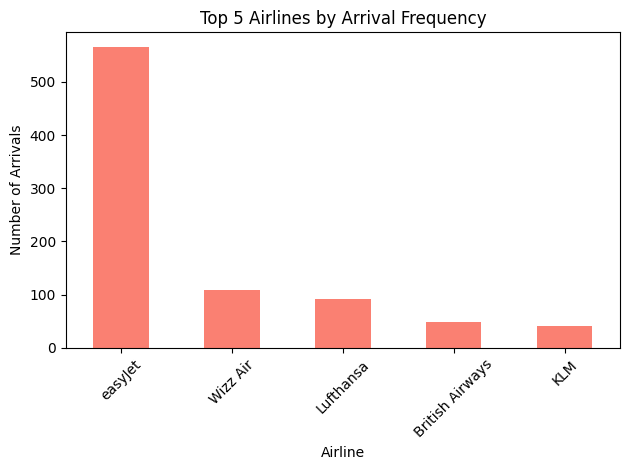

In [14]:
# Filter for Arrivals only
arrivals_df = df[df['Type'] == 'Arrivals']

# Find the top five airlines by frequency of arrivals
top_airlines = arrivals_df['Airline'].value_counts().head(5)

# Display the result
print("Top 5 Airlines by Arrival Frequency:")
print(top_airlines.to_frame(name='Number of Arrivals'))

# Optional: plotting the top airlines
top_airlines.plot(kind='bar', color='salmon')
plt.title("Top 5 Airlines by Arrival Frequency")
plt.xlabel("Airline")
plt.ylabel("Number of Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### RQ 3: Average delay time for arrivals and departures

Average Arrival Delay: -3.37 minutes
Average Departure Delay: 2.85 minutes


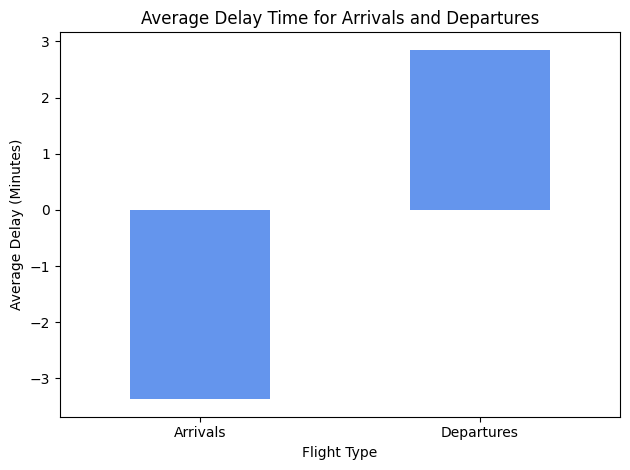

In [15]:
# Calculate average delay for arrivals and departures
average_arrival_delay = df[df['Type'] == 'Arrivals']['Delay'].mean()
average_departure_delay = df[df['Type'] == 'Departures']['Delay'].mean()

# Display results
print(f"Average Arrival Delay: {average_arrival_delay:.2f} minutes")
print(f"Average Departure Delay: {average_departure_delay:.2f} minutes")

# Prepare data for plotting
delay_data = pd.DataFrame({
    'Flight Type': ['Arrivals', 'Departures'],
    'Average Delay (Minutes)': [average_arrival_delay, average_departure_delay]
})

# Optional: plotting the average delay
ax = delay_data.plot(kind='bar', x='Flight Type', y='Average Delay (Minutes)', legend=False, color='cornflowerblue')

plt.title("Average Delay Time for Arrivals and Departures")
plt.xlabel("Flight Type")
plt.ylabel("Average Delay (Minutes)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()


### BONUS: Top 10 most frequet airlines and their ranking on average delay time for arrivals and departures

Top 10 Airlines with Most Average Delay in Arrivals:
Airline
FedEx                          -3.033333
European Air Transport / DHL   -3.035714
Air France                     -3.074074
British Airways                -3.102041
KLM                            -3.170732
Turkish Airlines               -3.214286
Wizz Air                       -3.305556
Pegasus Airlines               -3.322581
SunExpress                     -3.500000
easyJet                        -3.555752
Name: Delay, dtype: float64

Top 10 Airlines with Most Average Delay in Departures:
Airline
KLM                             5.046512
Lufthansa                       3.967742
Wizz Air                        3.779817
SunExpress                      3.656250
easyJet                         2.784512
Pegasus Airlines                2.129032
Air France                      1.740741
Turkish Airlines                1.285714
British Airways                 0.940000
European Air Transport / DHL    0.000000
Name: Delay, dtype: float64

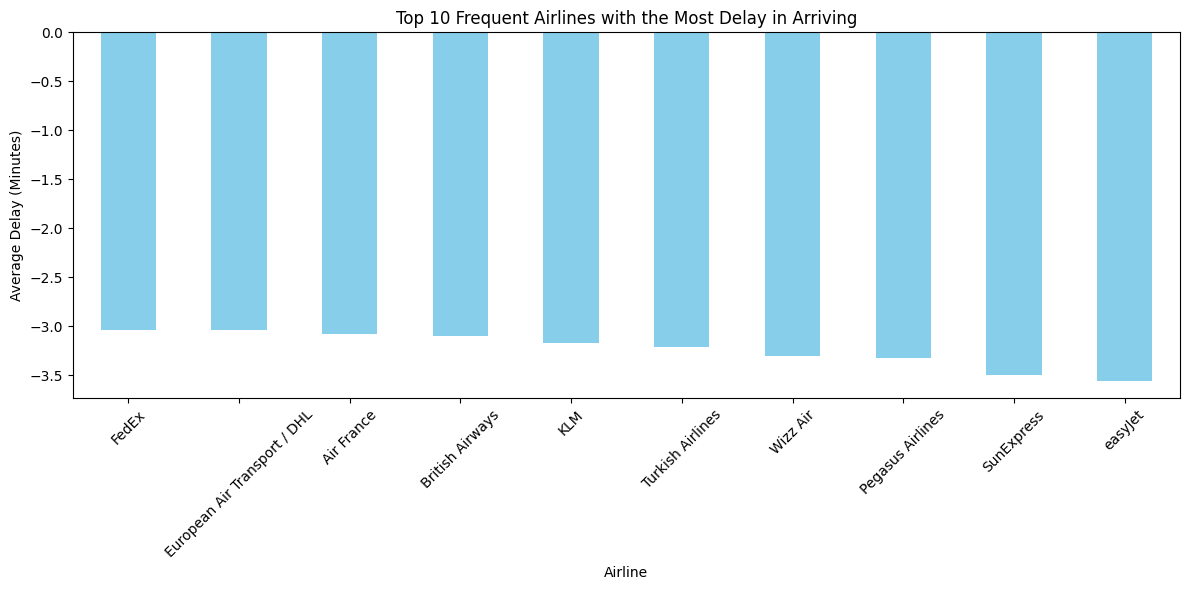

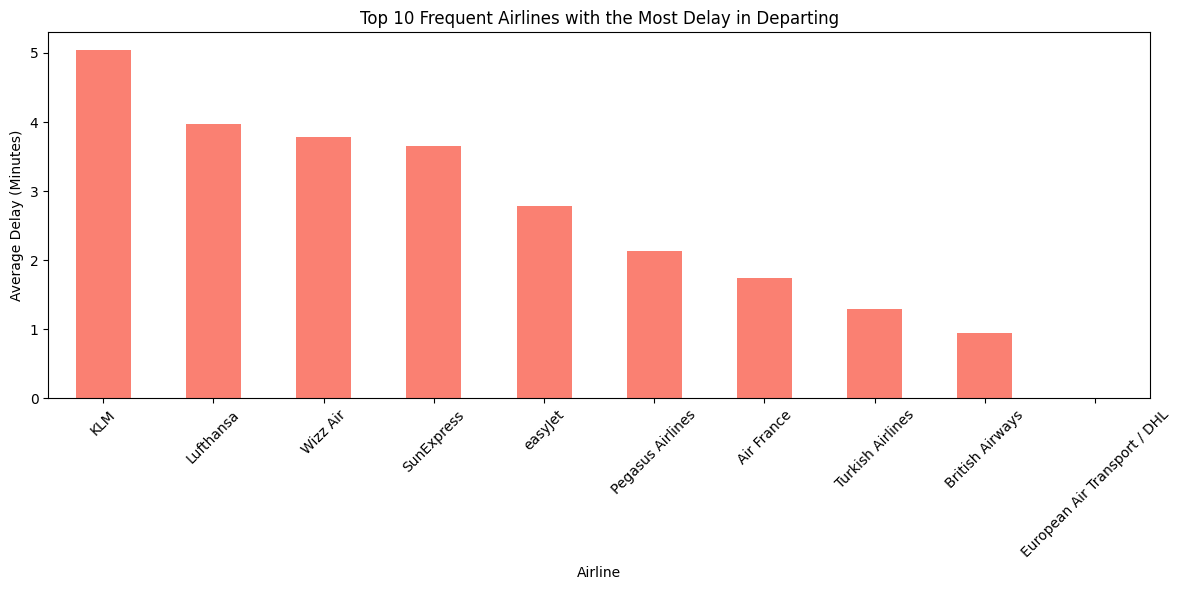

In [16]:
# Separate the DataFrame into arrivals and departures
arrivals_df = df[df['Type'] == 'Arrivals']
departures_df = df[df['Type'] == 'Departures']

# Identify the top 10 airlines with the greatest frequency in arrivals
top_10_arrival_airlines = arrivals_df['Airline'].value_counts().head(10).index

# Identify the top 10 airlines with the greatest frequency in departures
top_10_departure_airlines = departures_df['Airline'].value_counts().head(10).index

# Combine these lists to get the union of airlines appearing in either top 10 list
top_airlines = top_10_arrival_airlines.union(top_10_departure_airlines)

# Filter the main DataFrame to only include rows for these top airlines
top_airlines_df = df[df['Airline'].isin(top_airlines)]

# Calculate the average delay grouped by Airline and Type
average_delay_by_airline_and_type = top_airlines_df.groupby(['Airline', 'Type'])['Delay'].mean()

# Separate arrivals and departures, then rank them within each group
average_delay_arrivals = average_delay_by_airline_and_type.xs('Arrivals', level='Type').sort_values(ascending=False)
average_delay_departures = average_delay_by_airline_and_type.xs('Departures', level='Type').sort_values(ascending=False)

# Display the top 10 airlines with the most average delay in arrivals and departures
print("Top 10 Airlines with Most Average Delay in Arrivals:")
print(average_delay_arrivals.head(10))

print("\nTop 10 Airlines with Most Average Delay in Departures:")
print(average_delay_departures.head(10))

# Optional: plotting the results for Arrivals
plt.figure(figsize=(12, 6))
average_delay_arrivals.head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Frequent Airlines with the Most Delay in Arriving")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plotting the results for Departures
plt.figure(figsize=(12, 6))
average_delay_departures.head(10).plot(kind='bar', color='salmon')
plt.title("Top 10 Frequent Airlines with the Most Delay in Departing")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
